# Stellar Luminosity | Linear and Polynomial Regression Refresher

**Author:** Daniel Patiño Mejia

---
### Context

This notebook implements linear and polynomial regression from first principles (prediction, cost, gradients, and gradient descent, all hand-written with NumPy) to model the relationship between stellar mass and luminosity. The goal is to understand *how* a regression model learns from data, not just to call a library that does it for us.

---

### Driving technical question
---

- How does a regression model learn from data?

Learns from data finding a mathematical equation that links the input to a target number starting with random guesses, then, measuring its mistakes and changing it through iterations until finding the lowest one to make better predictions.

### 1. Setup


In [61]:

# Install required libraries (run this once if needed)
%pip install numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [62]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# Make NumPy output easier to read.
np.set_printoptions(precision=4, suppress=True)

# Libraries and language versions
print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

Python version: 3.14.6 (main, Jun 23 2026, 18:14:05) [GCC 16.1.1 20260430]
NumPy version: 2.5.1
Matplotlib version: 3.11.1


### 2. Load Stellar Luminosity Dataset

This is a small instructional dataset inspired by nonlinear main-sequence behavior, with the following features:

- mass: stellar mass in units of solar mass.
- luminosity: stellar luminosity in units of solar luminosity.

We store both as NumPy arrays, since all the regression code that follows works directly with arrays.

In [63]:
mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Confirm the dimensions/shapes
print("Mass Array Shape:", mass.shape)
print("Luminosity Shape:", luminosity.shape)

# Confirm the ranges (min and max values)
print("\nData Summary (Ranges):")
print(f"  mass:       min={mass.min():.2f}, max={mass.max():.2f}")
print(f"  luminosity: min={luminosity.min():.2f}, max={luminosity.max():.2f}")


Mass Array Shape: (10,)
Luminosity Shape: (10,)

Data Summary (Ranges):
  mass:       min=0.60, max=2.40
  luminosity: min=0.15, max=35.00


### 3. Exploring Stellar Luminosity



First we plot the stellar mass against stellar luminosity using Matplotlib.

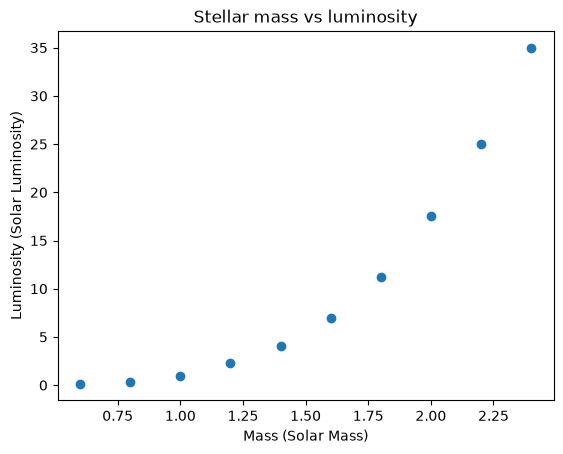

In [64]:
plt.figure()
plt.scatter(mass, luminosity)
plt.xlabel("Mass (Solar Mass)")
plt.ylabel("Luminosity (Solar Luminosity)")
plt.title("Stellar mass vs luminosity")
plt.show()

We can observe that the mass-luminosity relationship is proportional; this means that the star's energy increases as its mass increases.

---

**Is a straight line adequate? Where systematic errors might occur?**

- Given its non-linear nature (more close to a quartic), I do not believe a straight line is the most suitable choice; while we would find an approximate value, it would not be the closest possible one. The systematic error we would encounter is that the model has a limited capacity to represent the data curvature; even though gradient descent would converge to the best possible linear fit, it still deviates from the true values.

### 4. Implementing Learning Algorithm

First of all we compute the prediction using the following formula:

In [65]:
def predict(X, w, b):
    """Compute predictions f_{w,b}(x).

    X has shape (m, l): m mass and l luminosity.
    w has shape (l,): one weight per feature.
    b is a scalar bias term.
    """
    # X @ w computes one weighted sum per row of X.
    # Adding b shifts every prediction by the same amount.
    return X @ w + b

Then, we calculate the Mean Squared Error:

In [66]:
def compute_cost(X, y, w, b):
    """Compute the cost J(w,b) for linear regression with multiple features."""
    m = X.shape[0]

    # Compute predictions for all examples.
    y_hat = predict(X, w, b)

    # Compute the error for each example.
    error = y_hat - y

    # error @ error is the dot product of error with itself:
    # it is the same as summing error[i] ** 2 over all examples.
    cost = (error @ error) / (2 * m)

    return cost

Calculate the gradient respect to b and w

In [67]:
def compute_gradient(X, y, w, b):
    """Compute the gradients of J with respect to w and b."""
    m = X.shape[0]

    # Predictions and errors for all examples.
    y_hat = predict(X, w, b)
    error = y_hat - y

    # X.T has shape (n, m). Multiplying X.T @ error combines
    # each feature column with the error vector.
    dj_dw = (X.T @ error) / m

    # The derivative with respect to b is the average error.
    dj_db = np.sum(error) / m

    return dj_dw, dj_db

Now we calculate the gradient descent

In [68]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iterations, print_progress=True):
    """Run gradient descent to learn w and b."""
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        history_it.append(i)
        history_cost.append(cost)

        # Print about 10 progress updates, instead of printing every few steps.
        if print_progress and (i % max(1, num_iterations // 10) == 0 or i == num_iterations - 1):
            print(f"Iteration {i:5d}: cost = {cost:10.4f}")

    return w, b, history_it, history_cost

### 5. Training a Linear Model

It's time to train a linear model; for this training, we will use the representation X_linear = [mass]

In [69]:
X_linear = np.array([mass]).T
w_init_lin = np.zeros(1)
b_init_lin = 0.0
alpha_lin = 0.01
num_iterations_lin = 10000

w_learned_lin, b_learned_lin, history_it_lin, history_cost_lin = gradient_descent(
    X_linear, luminosity, w_init_lin, b_init_lin, alpha_lin, num_iterations_lin
)

print("\nLearned parameters:")
for name, value in zip(["mass"], w_learned_lin):
    print(f"{name:>10s}: {value:8.4f}")
print("bias b   :", b_learned_lin)


Iteration     0: cost =   112.0896
Iteration  1000: cost =    13.8142
Iteration  2000: cost =    10.3996
Iteration  3000: cost =     9.8860
Iteration  4000: cost =     9.8088
Iteration  5000: cost =     9.7972
Iteration  6000: cost =     9.7955
Iteration  7000: cost =     9.7952
Iteration  8000: cost =     9.7952
Iteration  9000: cost =     9.7951
Iteration  9999: cost =     9.7951

Learned parameters:
      mass:  18.1294
bias b   : -16.833888424078236


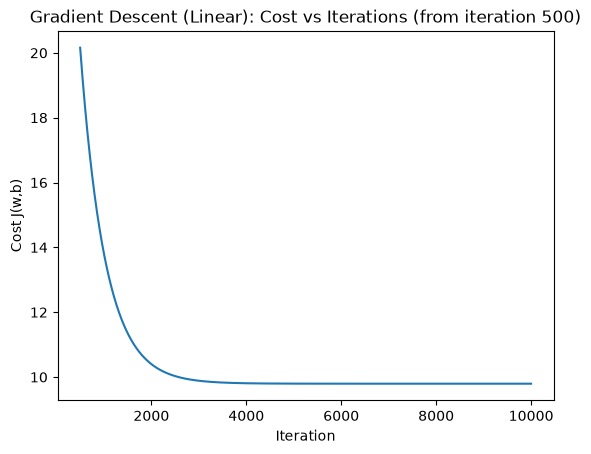

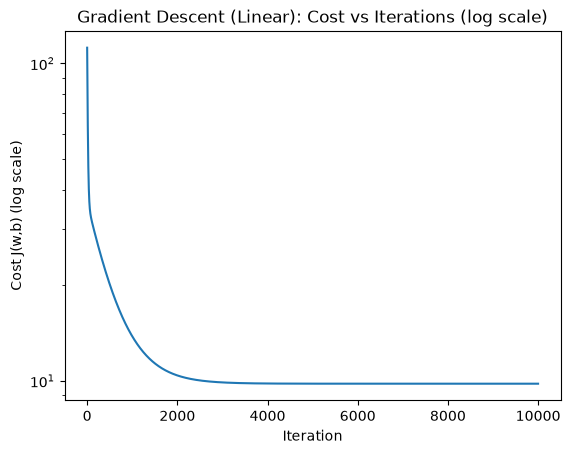

In [70]:
# Change this value to zoom into the cost curve.
# Use 0 to show all iterations.
# Try values like 100, 500, or 1000 to focus on later convergence.
start_iteration = 500

start_index = 0
for i in range(len(history_it_lin)):
    if history_it_lin[i] >= start_iteration:
        start_index = i
        break

fig, ax = plt.subplots()
ax.plot(history_it_lin[start_index:], history_cost_lin[start_index:])
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w,b)")
ax.set_title(f"Gradient Descent (Linear): Cost vs Iterations (from iteration {start_iteration})")
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
plt.show()

plt.figure()
plt.semilogy(history_it_lin, history_cost_lin)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b) (log scale)")
plt.title("Gradient Descent (Linear): Cost vs Iterations (log scale)")
plt.show()


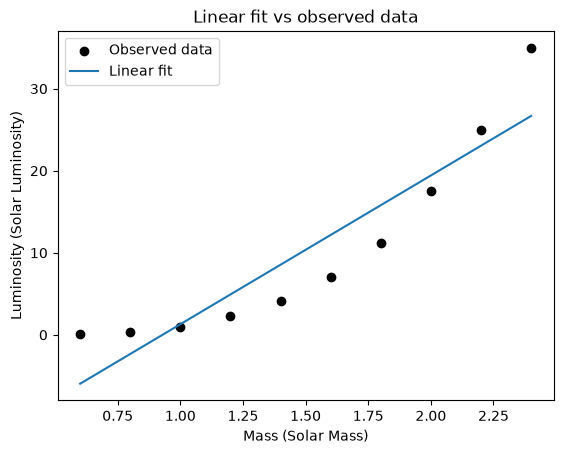

In [71]:
mass_grid = np.linspace(mass.min(), mass.max(), 200)
y_grid_lin = predict(mass_grid.reshape(-1, 1), w_learned_lin, b_learned_lin)

plt.figure()
plt.scatter(mass, luminosity, label="Observed data", color="black")
plt.plot(mass_grid, y_grid_lin, label="Linear fit", color="tab:blue")
plt.xlabel("Mass (Solar Mass)")
plt.ylabel("Luminosity (Solar Luminosity)")
plt.title("Linear fit vs observed data")
plt.legend()
plt.show()


**Convergence and Systematic Errors**

- The cost curve slows down around iteration 6000, indicating that gradient descent has converged for this learning rate and number of iterations. Subsequent iterations barely modify the cost, so it does not decrease significantly.

- However, the fitted line does not visibly follow the curvature of the data because it lies above the observations in the middle of the mass range and below them at the higher masses. This is precisely the systematic error predicted in previous sections, where the relationship appeared closer to a quartic than a straight line. Converging to the best possible straight line does not eliminate this inaccuracy; it only finds the least flawed straight line, which still does not reflect the actual curvature.

### 6. Training a Polynomial Model

It's time to train a polynomial model; for this training, we will use the representation X_polynomial = [$mass, {mass^2}$]

In [72]:
mass_2 = mass ** 2
X_polynomial = np.array([mass, mass_2]).T
w_init_poly = np.zeros(2)
b_init_poly = 0.0
alpha_poly = 0.01
num_iterations_poly = 10000

w_learned_poly, b_learned_poly, history_it_poly, history_cost_poly = gradient_descent(
    X_polynomial, luminosity, w_init_poly, b_init_poly, alpha_poly, num_iterations_poly
)

print("\nLearned parameters:")
for name, value in zip(["mass", "mass^2"], w_learned_poly):
    print(f"{name:>10s}: {value:8.4f}")
print("bias b   :", b_learned_poly)


Iteration     0: cost =    92.6099
Iteration  1000: cost =     2.9619
Iteration  2000: cost =     2.6621
Iteration  3000: cost =     2.4016
Iteration  4000: cost =     2.1701
Iteration  5000: cost =     1.9643
Iteration  6000: cost =     1.7813
Iteration  7000: cost =     1.6186
Iteration  8000: cost =     1.4740
Iteration  9000: cost =     1.3454
Iteration  9999: cost =     1.2312

Learned parameters:
      mass: -12.6747
    mass^2:  10.4373
bias b   : 2.387663229623033


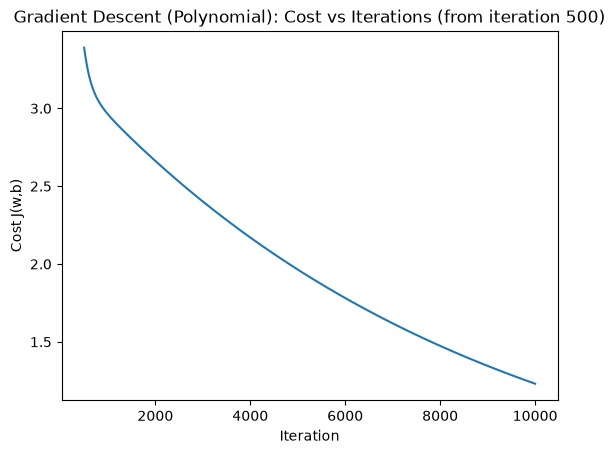

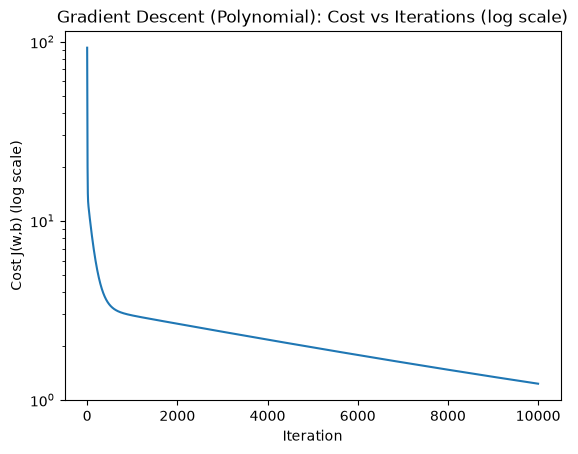

In [73]:
# Change this value to zoom into the cost curve.
# Use 0 to show all iterations.
# Try values like 100, 500, or 1000 to focus on later convergence.
start_iteration = 500

start_index = 0
for i in range(len(history_it_poly)):
    if history_it_poly[i] >= start_iteration:
        start_index = i
        break

fig, ax = plt.subplots()
ax.plot(history_it_poly[start_index:], history_cost_poly[start_index:])
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w,b)")
ax.set_title(f"Gradient Descent (Polynomial): Cost vs Iterations (from iteration {start_iteration})")
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
plt.show()

plt.figure()
plt.semilogy(history_it_poly, history_cost_poly)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b) (log scale)")
plt.title("Gradient Descent (Polynomial): Cost vs Iterations (log scale)")
plt.show()


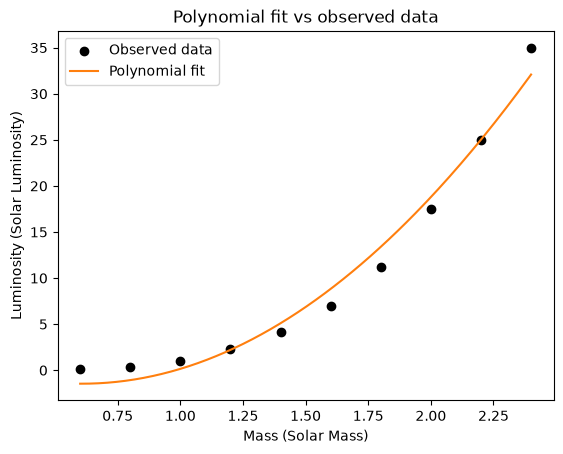

In [74]:
y_grid_poly = predict(np.array([mass_grid, mass_grid ** 2]).T, w_learned_poly, b_learned_poly)

plt.figure()
plt.scatter(mass, luminosity, label="Observed data", color="black")
plt.plot(mass_grid, y_grid_poly, label="Polynomial fit", color="tab:orange")
plt.xlabel("Mass (Solar Mass)")
plt.ylabel("Luminosity (Solar Luminosity)")
plt.title("Polynomial fit vs observed data")
plt.legend()
plt.show()


**What changed, and what stayed the same**

- **Changed:** the design matrix now has two columns (mass and mass²) instead of one, so w_init_poly / w_learned_poly have two entries instead of one; the model has one more learned parameter (the mass² coefficient) alongside a different bias term.

- The fitted curve above tracks the upward bend of the data much more closely than the straight line did for the linear model.

### 7. Comparing the Linear and Polynomial Models

Now that both models are trained, we compare them side by side: their final training cost, their residuals, and how their fitted curves look against the observed data.

In [75]:
final_cost_lin = history_cost_lin[-1]
final_cost_poly = history_cost_poly[-1]

print(f"Final cost (Linear):     {final_cost_lin:10.4f}")
print(f"Final cost (Polynomial): {final_cost_poly:10.4f}")
print(f"\nRatio (linear / polynomial): {final_cost_lin / final_cost_poly:.2f}x")


Final cost (Linear):         9.7951
Final cost (Polynomial):     1.2312

Ratio (linear / polynomial): 7.96x


As we can see, the linear cost is greater than the polynomial by approximately 8 times, which shows that the polynomial model has better prediction and approximation to the real target values.

#### Residuals

A residual is (**observed - predicted**) for each star. Plotting residuals lets us see *how* a model is wrong, not just *how much* — a random scatter around zero suggests a good fit, while a visible curve or trend in the residuals means the model is missing structure in the data.

Residuals (Linear):     [ 6.1063  2.6804 -0.2955 -2.6213 -4.4472 -5.1731 -4.599  -1.9248  1.9493
  8.3234]
Residuals (Polynomial): [ 1.6097  1.4222  0.8497  0.0922 -1.0002 -1.8277 -2.1901 -1.2875 -0.0199
  2.9127]


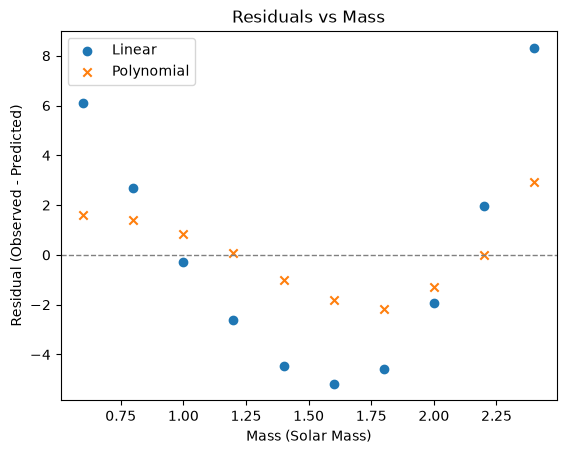

In [76]:
y_hat_lin = predict(X_linear, w_learned_lin, b_learned_lin)
y_hat_poly = predict(X_polynomial, w_learned_poly, b_learned_poly)

residuals_lin = luminosity - y_hat_lin
residuals_poly = luminosity - y_hat_poly

print("Residuals (Linear):    ", residuals_lin)
print("Residuals (Polynomial):", residuals_poly)

fig, ax = plt.subplots()
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.scatter(mass, residuals_lin, label="Linear", marker="o")
ax.scatter(mass, residuals_poly, label="Polynomial", marker="x")
ax.set_xlabel("Mass (Solar Mass)")
ax.set_ylabel("Residual (Observed - Predicted)")
ax.set_title("Residuals vs Mass")
ax.legend()
plt.show()


#### Fitted models vs observations

To watch the models difference, we overlay both fitted curves on top of the original scatter plot to compare how well each one tracks the data across the observed mass range.

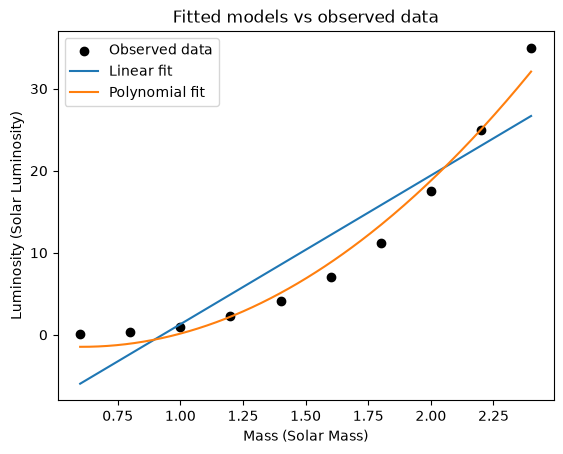

In [77]:
mass_grid = np.linspace(mass.min(), mass.max(), 200)

y_grid_lin = predict(mass_grid.reshape(-1, 1), w_learned_lin, b_learned_lin)
y_grid_poly = predict(np.array([mass_grid, mass_grid ** 2]).T, w_learned_poly, b_learned_poly)

plt.figure()
plt.scatter(mass, luminosity, label="Observed data", color="black")
plt.plot(mass_grid, y_grid_lin, label="Linear fit")
plt.plot(mass_grid, y_grid_poly, label="Polynomial fit")
plt.xlabel("Mass (Solar Mass)")
plt.ylabel("Luminosity (Solar Luminosity)")
plt.title("Fitted models vs observed data")
plt.legend()
plt.show()


**Which model best represents the observed range and why?**

- The polynomial model achieves the lowest final training cost of the two models (1.2312 vs. 9.7951 — about 8 times lower) and exhibits smaller residuals across almost the entire mass range, as can be seen in the residual plot. Its largest residual is about 2.91 solar luminosities (at the highest-mass star), versus about 8.32 for the linear model at that same star — a difference also reflected in the sum of squared residuals (≈24.6 for the polynomial vs. ≈195.9 for the linear model, again roughly 8x smaller).

- The residual plot shows *why*: the residuals of the linear model are not randomly dispersed around zero, but rather exhibit negative values in the central part of the mass range and become sharply positive at the highest masses. This is characteristic of a straight line, as it fails to follow an upward curve. The residuals of the polynomial model are smaller and better distributed, although they maintain a slight curve, which suggests that even mass² does not completely capture the actual shape of the mass-luminosity relationship observed earlier, but approximates it quite well.

**Warning: Lower training cost is not proof of scientific validity.**

- We can think of the linear model as a special case of the polynomial model (the case where the mass² coefficient is exactly zero), so the polynomial's training cost can only be lower than or equal to the linear model's — never greater. A lower cost is expected from the model's construction alone; it does not by itself mean that mass² is a physically or scientifically meaningful term.

- With only 10 data points and no reserved validation data, we cannot verify whether the additional flexibility captures the actual structure or simply fits the noise in this particular sample. A model can achieve a good training score and still generalize poorly to new stars.

- Both models were evaluated only in-sample, and only within the observed mass range; there is no justification for extrapolating either fitted curve to masses outside the range [0.6, 2.4] solar masses.

### 8. Test the Boundary of the Evidence

We now ask both trained models to predict luminosity for two masses: 1.3 (inside the observed range) and 5.0 (far outside it). We will compare the results and explain whether the available data justifies trusting each prediction.

In [78]:
test_masses = np.array([1.3, 5.0])

y_pred_lin = predict(test_masses.reshape(-1, 1), w_learned_lin, b_learned_lin)
y_pred_poly = predict(np.array([test_masses, test_masses ** 2]).T, w_learned_poly, b_learned_poly)

print(f"Observed mass range: [{mass.min()}, {mass.max()}] solar masses\n")
for m, y_lin, y_poly in zip(test_masses, y_pred_lin, y_pred_poly):
    location = "inside" if mass.min() <= m <= mass.max() else "OUTSIDE"
    print(f"mass = {m:>4.1f} ({location} observed range): "
          f"linear = {y_lin:8.4f}, polynomial = {y_poly:8.4f}, diff = {abs(y_lin - y_poly):8.4f}")


Observed mass range: [0.6, 2.4] solar masses

mass =  1.3 (inside observed range): linear =   6.7343, polynomial =   3.5496, diff =   3.1847
mass =  5.0 (OUTSIDE observed range): linear =  73.8129, polynomial = 199.9471, diff = 126.1342


**Mass = 1.3 (interpolation within the observed range [0.6, 2.4])**

- This mass falls between two actual observations (1.2 → 2.30 and 1.4 → 4.10 solar luminosities), so it is an interpolation: the type of prediction that training data can support.

- The linear model predicts approximately 6.73, while the polynomial model predicts 3.55 — a difference of about 3.18. Compared to the neighboring observed values, the linear prediction is already too high to be plausible, while the polynomial prediction falls within a much more reasonable range. This matches the residual pattern we saw in the model comparison in the previous section: the linear model systematically overestimates luminosity through the middle of the mass range.

- **Reliability:** reasonable for the polynomial prediction, low for the linear one. We have nearby actual data to check both against, and only one matches the local trend.

**Mass = 5.0 (extrapolation — more than double the maximum observed mass)**

- No star in the dataset comes close to this mass (the heaviest observed star has 2.4 solar masses). This is a pure extrapolation, with no data constraining it.

- The two models now differ enormously: the linear model predicts approximately 73.81, the polynomial model 199.95 — a gap of about 126.13, far too large to reconcile. Small differences between the fitted curves near the training data are magnified far away from it, since the mass² term grows much faster than the linear term as mass increases.

- **Reliability:** low for both. Neither the model's training cost, nor its residuals, nor its fit quality within the observed range say anything about behavior at mass = 5.0. Trusting either number here means relying on the shape of an equation, not on evidence — the same mistake flagged in the previous section: a lower cost (or a more flexible model) is not the same as scientific validity.

### 9. Reflect on Artificial Intelligence

- What does this regression experiment reveal—and what doesn't it reveal—about how the most advanced AI systems learn?

Answer: This regression experiment reveals that AI systems can learn patterns from data by optimizing mathematical parameters to minimize the prediction error. It shows that the learning process is fundamentally an optimization process more than memorization. Also, i feel that regression in some cases doesn't reveal the absolute truth about the data, as happened in some cases where we might obtain a low cost, but one far from the actual target. However, it doesn't reveal how advanced AI systems learn complex reasoning, language or planning processes. As conclusion, i think that regression is the tip of the iceberg of machine learning methods.

- Do you think Artificial General Intelligence (AGI) is achievable? Explain what you understand by AGI and why you think it is—or isn't—achievable.

Ans: I understand artificial general intelligence to be a field of research that attempts to develop software with human-like intelligence and the capacity for self-learning to perform tasks for which it wasn't necessarily designed or trained. I feel that at some point it will be achievable. Today, the advancement of artificial intelligence has been exponential compared to what we saw in previous years. However, its responses are still based on data processing rather than thought in the way a human being would. There are still several more years of studying the human brain (which is a very large field) before AGIs can begin to be developed.

- Could AGI emerge primarily by expanding neural networks with more GPUs, data, and parameters? Or will it require fundamentally different architectures, learning mechanisms, theories, or ways of interacting with the world?

Ans: No, primarily, scaling resources or networks would allow improvements on the model capacity to learn new complex patterns, improve generalization and learn more emergent abilities. However, I feel that to have an AI system, it would require some precise way of replicating the human brain, perhaps by changing aspects of architecture, interactions with the world, and implementations.

- A question about AI-powered systems that I want to explore this semester is: Could AI eventually enable the creation of complete digital replicas of human beings, including their organs, physiology, and behavior?